In [1]:
# ALL LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, accuracy_score, f1_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [2]:
# Dataset loading
df = pd.read_excel("E_Commerce_Dataset.xlsx")

print("Shape:", df.shape)
print(df.head())
df.info()
df.describe()

Shape: (5630, 20)
   CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  WarehouseToHome  \
0       50001      1     4.0         Mobile Phone         3              6.0   
1       50002      1     NaN                Phone         1              8.0   
2       50003      1     NaN                Phone         1             30.0   
3       50004      1     0.0                Phone         3             15.0   
4       50005      1     0.0                Phone         1             12.0   

  PreferredPaymentMode  Gender  HourSpendOnApp  NumberOfDeviceRegistered  \
0           Debit Card  Female             3.0                         3   
1                  UPI    Male             3.0                         4   
2           Debit Card    Male             2.0                         4   
3           Debit Card    Male             2.0                         4   
4                   CC    Male             NaN                         3   

     PreferedOrderCat  SatisfactionScore Mar

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [3]:
# Checking Nan
print(df.isna().sum())

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64


In [4]:
# Class Distribution
print(df['Churn'].value_counts(normalize=True))

Churn
0    0.831616
1    0.168384
Name: proportion, dtype: float64


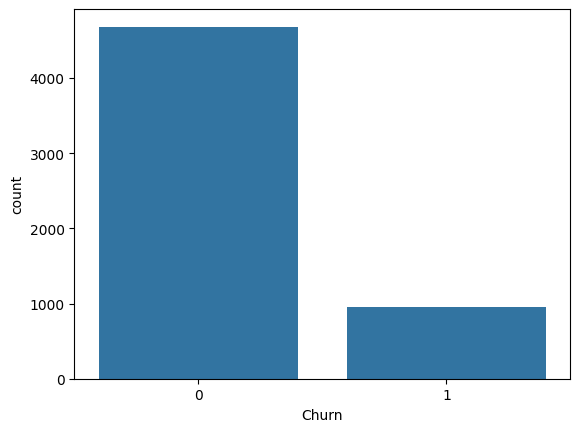

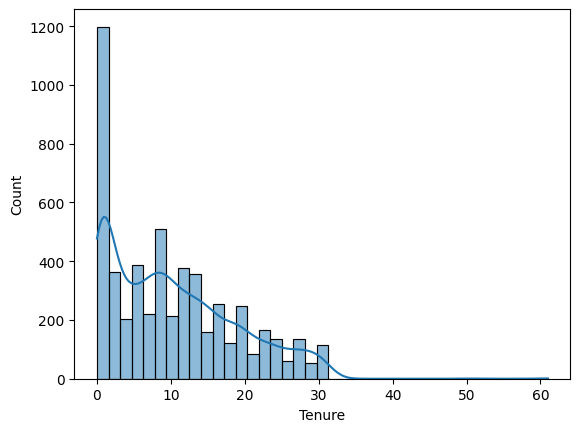

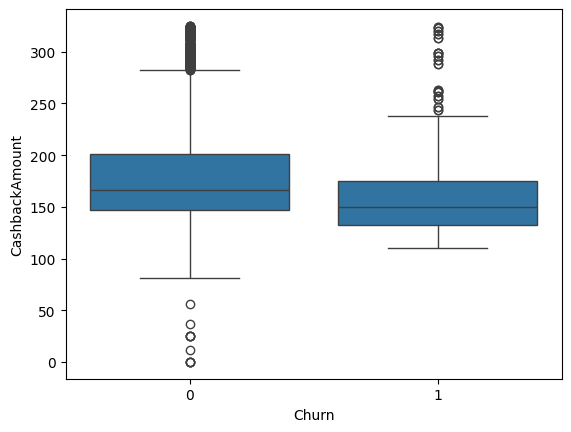

In [5]:
# Visualization
sns.countplot(x='Churn', data=df)
plt.show()
sns.histplot(df['Tenure'], kde=True)
plt.show()
sns.boxplot(x='Churn', y='CashbackAmount', data=df)
plt.show()

In [6]:
# Phase 2
# Cleaning Data
# Dropping unnecessary columns and filling missing values

df = df.drop(columns=["CustomerID"])

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(exclude=['int64', 'float64']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [7]:
# Encoding Categorical Variables
df = pd.get_dummies(df, drop_first=True)

In [8]:
# train_test_split and validation
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [9]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [10]:
# SMOTE for handling Imbalance dataset
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
print("After SMOTE:", np.bincount(y_train))

After SMOTE: [3277 3277]


In [11]:
# Model
lr = LogisticRegression(max_iter = 1000)
lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [12]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
# XGBoost 
xgb = XGBClassifier(eval_metric='logloss',random_state=42)
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [14]:
# Evalutaion Metrics
def evaluate(model, X, y):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:,1]

    print(classification_report(y, preds))
    print("ROC-AUC:", roc_auc_score(y, probs))

In [15]:
print("Logistic Regression")
evaluate(lr, X_test, y_test)

print("Random Forest")
evaluate(rf, X_test, y_test)

print("XGBoost")
evaluate(xgb, X_test, y_test)

Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.81      0.88       703
           1       0.48      0.85      0.61       142

    accuracy                           0.82       845
   macro avg       0.72      0.83      0.75       845
weighted avg       0.88      0.82      0.84       845

ROC-AUC: 0.9010177709214031
Random Forest
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       703
           1       0.90      0.81      0.85       142

    accuracy                           0.95       845
   macro avg       0.93      0.90      0.91       845
weighted avg       0.95      0.95      0.95       845

ROC-AUC: 0.9859655801093903
XGBoost
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       703
           1       0.94      0.88      0.91       142

    accuracy                           0.97       845
   macro avg       0.96      0

In [16]:
# Hyperparameter tuning OF LOGISTIC REGRESSION
lr_params = {
    'C': [0.01, 0.1, 1, 10]
}

lr_grid = GridSearchCV(lr, lr_params, cv=5, scoring='roc_auc', n_jobs=-1)
lr_grid.fit(X_train, y_train)

best_lr = lr_grid.best_estimator_
print("Best LR:", lr_grid.best_params_)

Best LR: {'C': 1}


In [17]:
# Hyperparameter tuning OF RANDOM FOREST
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print("Best RF:", rf_grid.best_params_)

Best RF: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [18]:
# Hyperparameter tuning OF XGBOOST
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(xgb, xgb_params, cv=5, scoring='roc_auc', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
print("Best XGB:", xgb_grid.best_params_)

Best XGB: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100, 'subsample': 1.0}


In [19]:
# METRICS TABLE
def get_metrics(model, X, y):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:,1]

    return {
        "Accuracy": accuracy_score(y, preds),
        "F1": f1_score(y, preds),
        "ROC-AUC": roc_auc_score(y, probs)
    }

results = pd.DataFrame({
    "Logistic Regression": get_metrics(best_lr, X_test, y_test),
    "Random Forest": get_metrics(best_rf, X_test, y_test),
    "XGBoost": get_metrics(best_xgb, X_test, y_test)
}).T

print(results)

                     Accuracy        F1   ROC-AUC
Logistic Regression  0.820118  0.614213  0.901018
Random Forest        0.953846  0.856089  0.985134
XGBoost              0.979882  0.939068  0.989081


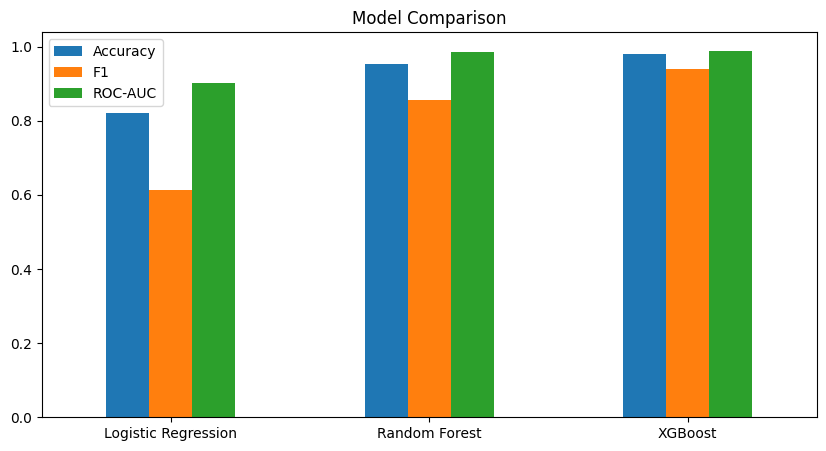

In [20]:
# VISUALIZATION
results.plot(kind='bar', figsize=(10,5))
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.show()

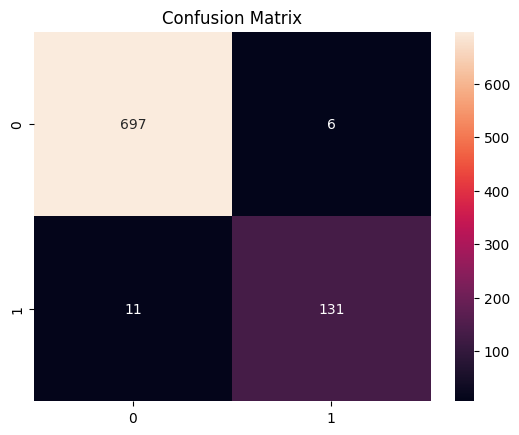

In [21]:
# CONFUSION MATRIX
sns.heatmap(confusion_matrix(y_test, best_xgb.predict(X_test)), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

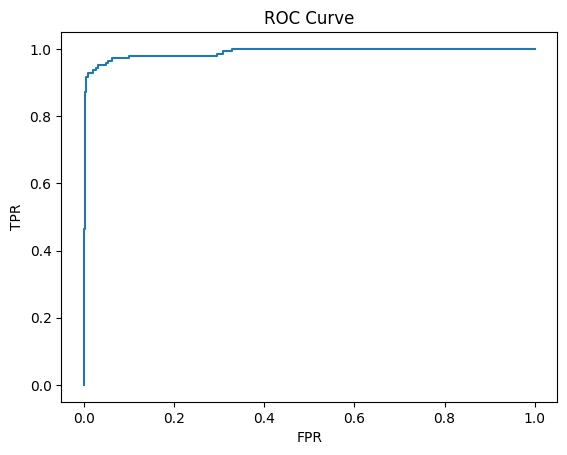

In [22]:
# ROC CURVE
fpr, tpr, _ = roc_curve(y_test, best_xgb.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

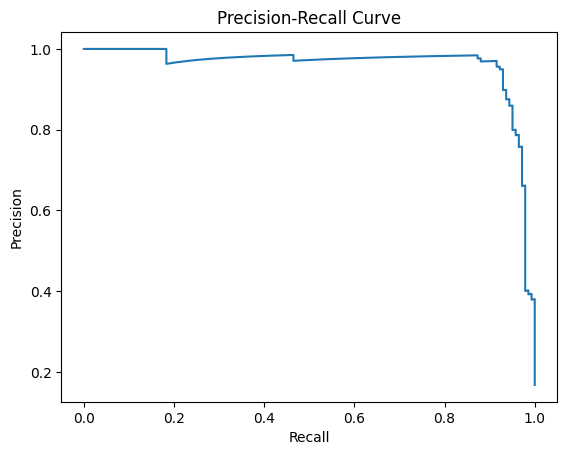

In [23]:
# Precision Recall Curve
precision, recall, _ = precision_recall_curve(
    y_test, best_xgb.predict_proba(X_test)[:,1]
)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

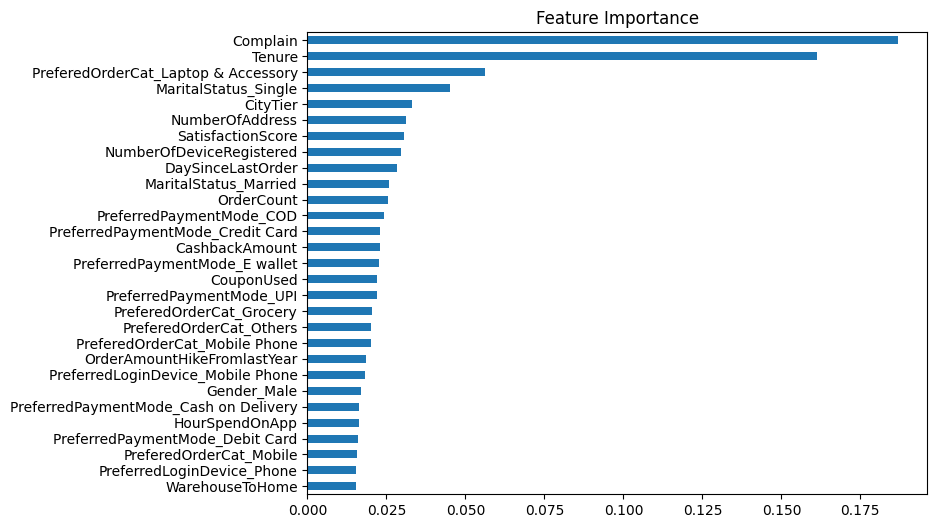

In [24]:
# Feature Importance
importance = best_xgb.feature_importances_
features = X.columns

pd.Series(importance, index=features).sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

In [25]:
# Cross Val 
scores = cross_val_score(best_xgb, X_train, y_train, cv=5, scoring='roc_auc')

print("Mean ROC-AUC:", scores.mean())
print("Std Dev:", scores.std())

Mean ROC-AUC: 0.9953712565786574
Std Dev: 0.007589900429383579


In [26]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [27]:
df.head()

,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,...,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,1,4.0,3,6.0,3.0,3,2,9,1,11.0,...,False,False,False,False,True,False,False,False,False,True
1,1,9.0,1,8.0,3.0,4,3,7,1,15.0,...,False,True,True,False,False,True,False,False,False,True
2,1,9.0,1,30.0,2.0,4,3,6,1,14.0,...,False,False,True,False,False,True,False,False,False,True
3,1,0.0,3,15.0,2.0,4,5,8,0,23.0,...,False,False,True,False,True,False,False,False,False,True
4,1,0.0,1,12.0,3.0,3,5,3,0,11.0,...,False,False,True,False,False,True,False,False,False,True


In [28]:
def plot_confusion_matrix(model, X, y, title):
    preds = model.predict(X)
    cm = confusion_matrix(y, preds)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=True,
        xticklabels=['Predicted 0', 'Predicted 1'],
        yticklabels=['Actual 0', 'Actual 1']
    )

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

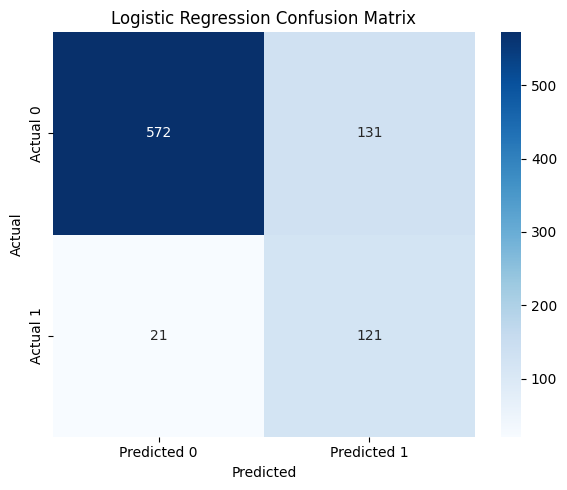

In [29]:
plot_confusion_matrix(best_lr, X_test, y_test, "Logistic Regression Confusion Matrix")

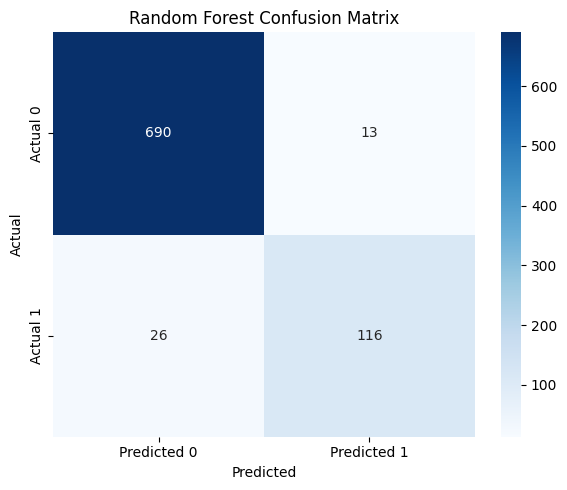

In [30]:
plot_confusion_matrix(best_rf, X_test, y_test, "Random Forest Confusion Matrix")

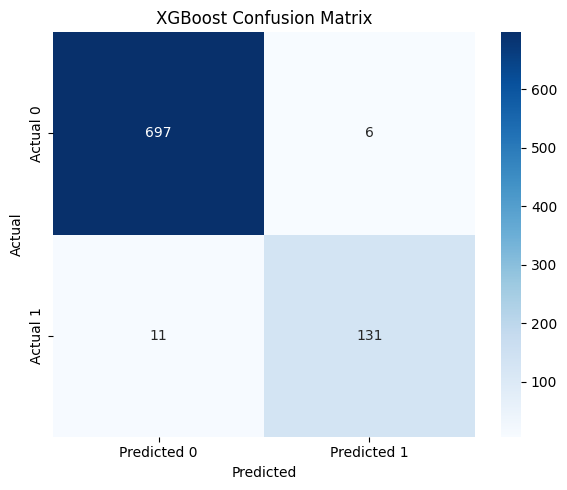

In [31]:
plot_confusion_matrix(best_xgb, X_test, y_test, "XGBoost Confusion Matrix")

In [32]:
results = pd.DataFrame({
    "Logistic Regression": get_metrics(best_lr, X_test, y_test),
    "Random Forest": get_metrics(best_rf, X_test, y_test),
    "XGBoost": get_metrics(best_xgb, X_test, y_test)
}).T

results = results.round(3)

results

,Accuracy,F1,ROC-AUC
Logistic Regression,0.820,0.614,0.901
Random Forest,0.954,0.856,0.985
XGBoost,0.980,0.939,0.989


In [33]:
pd.set_option('display.max_columns', None)
df.head()

,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,PreferredLoginDevice_Mobile Phone,PreferredLoginDevice_Phone,PreferredPaymentMode_COD,PreferredPaymentMode_Cash on Delivery,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,1,4.0,3,6.0,3.0,3,2,9,1,11.0,1.0,1.0,5.0,159.93,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True
1,1,9.0,1,8.0,3.0,4,3,7,1,15.0,0.0,1.0,0.0,120.90,False,True,False,False,False,False,False,True,True,False,False,True,False,False,False,True
2,1,9.0,1,30.0,2.0,4,3,6,1,14.0,0.0,1.0,3.0,120.28,False,True,False,False,False,True,False,False,True,False,False,True,False,False,False,True
3,1,0.0,3,15.0,2.0,4,5,8,0,23.0,0.0,1.0,3.0,134.07,False,True,False,False,False,True,False,False,True,False,True,False,False,False,False,True
4,1,0.0,1,12.0,3.0,3,5,3,0,11.0,1.0,1.0,3.0,129.60,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,True


In [34]:
df.head(17).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
Churn,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Tenure,4.0,9.0,9.0,0.0,0.0,0.0,9.0,9.0,13.0,9.0,4.0,11.0,0.0,0.0,9.0,9.0,0.0
CityTier,3,1,1,3,1,1,3,1,3,1,1,1,1,1,3,2,1
WarehouseToHome,6.0,8.0,30.0,15.0,12.0,22.0,11.0,6.0,9.0,31.0,18.0,6.0,11.0,15.0,15.0,12.0,12.0
HourSpendOnApp,3.0,3.0,2.0,2.0,3.0,3.0,2.0,3.0,3.0,2.0,2.0,3.0,2.0,3.0,3.0,3.0,3.0
NumberOfDeviceRegistered,3,4,4,4,3,5,3,3,4,5,3,4,3,4,4,3,4
SatisfactionScore,2,3,3,5,5,5,2,2,3,3,3,3,3,3,2,5,2
NumberOfAddress,9,7,6,8,3,2,4,3,2,2,2,10,2,1,2,5,2
Complain,1,1,1,0,0,1,0,1,1,0,0,1,1,1,0,1,1
OrderAmountHikeFromlastYear,11.0,15.0,14.0,23.0,11.0,22.0,14.0,16.0,14.0,12.0,15.0,13.0,13.0,17.0,16.0,22.0,18.0
